
### House Price Prediction - India Real Estate
### Author: Suhana
### Date: April 2026

### Objective:
### Analyze factors affecting house prices in India
### and build ML models to predict house prices.

### Dataset: Indian Real Estate Listings (187,531 rows)
### Models: Linear Regression, Decision Tree, Random Forest

## 1. Importing Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error



## 2. Data Understanding

In [2]:
df = pd.read_csv("/kaggle/input/datasets/juhibhojani/house-price/house_prices.csv")
print(df.shape)
print("\n")
print(df.head())
print("\n")
print(df.isnull().sum())

(187531, 21)


   Index                                              Title  \
0      0  1 BHK Ready to Occupy Flat for sale in Srushti...   
1      1  2 BHK Ready to Occupy Flat for sale in Dosti V...   
2      2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
3      3        1 BHK Ready to Occupy Flat for sale Kasheli   
4      4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   

                                         Description Amount(in rupees)  \
0  Bhiwandi, Thane has an attractive 1 BHK Flat f...           42 Lac    
1  One can find this stunning 2 BHK flat for sale...           98 Lac    
2  Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
3  This beautiful 1 BHK Flat is available for sal...           25 Lac    
4  This lovely 2 BHK Flat in Pokhran Road, Thane ...          1.60 Cr    

   Price (in rupees) location Carpet Area         Status         Floor  \
0             6000.0    thane    500 sqft  Ready to Move  10 out of 11   
1            

## 3. Data Cleaning

In [3]:
# Drop useless columns
df.drop(columns=['Dimensions', 'Plot Area', 'Society', 
                 'Car Parking', 'Super Area', 'overlooking',
                 'Index', 'Title', 'Description'], inplace=True)

# Drop rows where target variable is missing
df.dropna(subset=['Price (in rupees)'], inplace=True)

print(df.shape)
print("\n")
print(df.isnull().sum())

(169866, 12)


Amount(in rupees)        0
Price (in rupees)        0
location                 0
Carpet Area          76235
Status                 595
Floor                 6843
Transaction              6
Furnishing            2060
facing               62052
Bathroom               754
Balcony              45062
Ownership            58237
dtype: int64


In [4]:
# Convert Bathroom to numeric first
df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')

# Now fill missing with median
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())

# Fill categorical columns
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])
df['Transaction'] = df['Transaction'].fillna(df['Transaction'].mode()[0])
df['Furnishing'] = df['Furnishing'].fillna(df['Furnishing'].mode()[0])
df['Ownership'] = df['Ownership'].fillna(df['Ownership'].mode()[0])

# Drop remaining missing rows
df.dropna(subset=['Carpet Area', 'Balcony', 'Floor'], inplace=True)

print(df.shape)
print("\n")
print(df.isnull().sum())

(87526, 12)


Amount(in rupees)        0
Price (in rupees)        0
location                 0
Carpet Area              0
Status                   0
Floor                    0
Transaction              0
Furnishing               0
facing               13660
Bathroom                 0
Balcony                  0
Ownership                0
dtype: int64


In [5]:
print(df.dtypes)
print("\n")
print(df['Carpet Area'].head())
print(df['Floor'].head())
print(df['Balcony'].head())

Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area           object
Status                object
Floor                 object
Transaction           object
Furnishing            object
facing                object
Bathroom             float64
Balcony               object
Ownership             object
dtype: object


0      500 sqft
9      900 sqft
13    1820 sqft
15     675 sqft
16     647 sqft
Name: Carpet Area, dtype: object
0     10 out of 11
9      3 out of 27
13    18 out of 27
15    10 out of 16
16      5 out of 7
Name: Floor, dtype: object
0     2
9     1
13    1
15    1
16    2
Name: Balcony, dtype: object


In [6]:
# Extract numeric value from Carpet Area
df['Carpet Area'] = df['Carpet Area'].str.extract(r'(\d+)').astype(float)

# Extract floor number from Floor column
df['Floor'] = df['Floor'].str.extract(r'(\d+)').astype(float)

# Convert Balcony to numeric
df['Balcony'] = pd.to_numeric(df['Balcony'], errors='coerce')

print(df[['Carpet Area', 'Floor', 'Balcony']].head())
print("\n")
print(df.dtypes)

    Carpet Area  Floor  Balcony
0         500.0   10.0      2.0
9         900.0    3.0      1.0
13       1820.0   18.0      1.0
15        675.0   10.0      1.0
16        647.0    5.0      2.0


Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area          float64
Status                object
Floor                float64
Transaction           object
Furnishing            object
facing                object
Bathroom             float64
Balcony              float64
Ownership             object
dtype: object


In [7]:
# Drop Amount column - we use Price (in rupees) as target
df.drop(columns=['Amount(in rupees)'], inplace=True)

# Encode categorical columns
df = pd.get_dummies(df, columns=['Status', 'Transaction', 
                                  'Furnishing', 'Ownership'], 
                                  drop_first=True)

# Encode location - too many unique values, use label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

print(df.shape)
print(df.dtypes)

(87526, 14)
Price (in rupees)              float64
location                         int64
Carpet Area                    float64
Floor                          float64
facing                          object
Bathroom                       float64
Balcony                        float64
Transaction_Other                 bool
Transaction_Resale                bool
Furnishing_Semi-Furnished         bool
Furnishing_Unfurnished            bool
Ownership_Freehold                bool
Ownership_Leasehold               bool
Ownership_Power Of Attorney       bool
dtype: object


In [8]:
df = df.drop(columns=['facing'], errors='ignore')

## 4. Exploratory Data Analysis

count    8.752600e+04
mean     8.170868e+03
std      3.421907e+04
min      0.000000e+00
25%      4.521000e+03
50%      6.300000e+03
75%      1.066700e+04
max      6.700000e+06
Name: Price (in rupees), dtype: float64




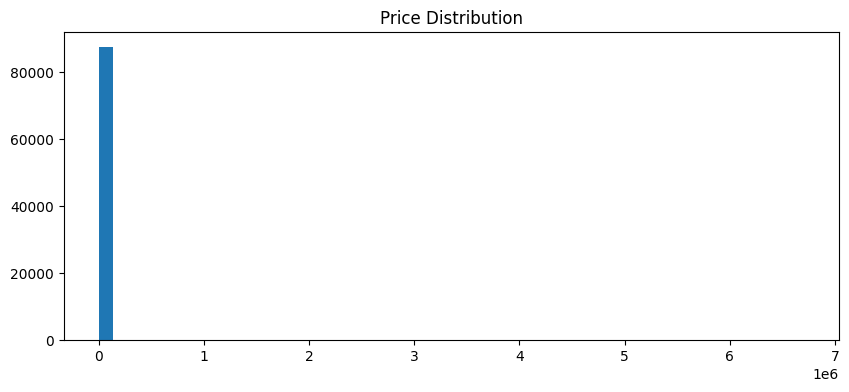

In [9]:
print(df['Price (in rupees)'].describe())
print("\n")
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.hist(df['Price (in rupees)'], bins=50)
plt.title('Price Distribution')
plt.show()

In [10]:
# Remove outliers using IQR method
Q1 = df['Price (in rupees)'].quantile(0.25)
Q3 = df['Price (in rupees)'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[(df['Price (in rupees)'] >= Q1 - 1.5*IQR) & 
              (df['Price (in rupees)'] <= Q3 + 1.5*IQR)]

print("Rows before:", df.shape[0])
print("Rows after:", df_clean.shape[0])
print("\n")
print(df_clean['Price (in rupees)'].describe())

Rows before: 87526
Rows after: 83902


count    83902.000000
mean      7268.724464
std       3633.973147
min          0.000000
25%       4500.000000
50%       6168.500000
75%       9868.750000
max      19841.000000
Name: Price (in rupees), dtype: float64


## 5. Feature Scaling & Model Building

In [11]:
from sklearn.preprocessing import MinMaxScaler

df_clean = df_clean.dropna()


X = df_clean.drop('Price (in rupees)', axis=1)
y = df_clean['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Comparison Table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [round(r2_score(y_test, lr_pred), 4),
                 round(r2_score(y_test, dt_pred), 4),
                 round(r2_score(y_test, rf_pred), 4)],
    'MSE': [round(mean_squared_error(y_test, lr_pred), 2),
            round(mean_squared_error(y_test, dt_pred), 2),
            round(mean_squared_error(y_test, rf_pred), 2)]
})

print(comparison)

               Model  R2 Score          MSE
0  Linear Regression    0.1904  10744080.02
1      Decision Tree    0.8013   2636597.43
2      Random Forest    0.8863   1509374.29


## 6. Results & Visualization

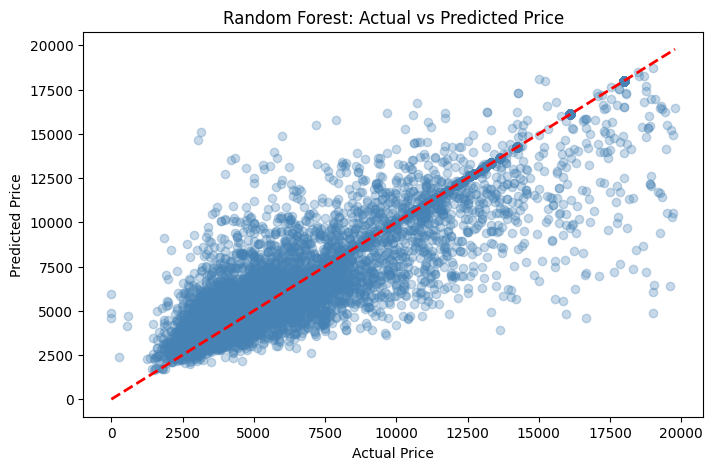

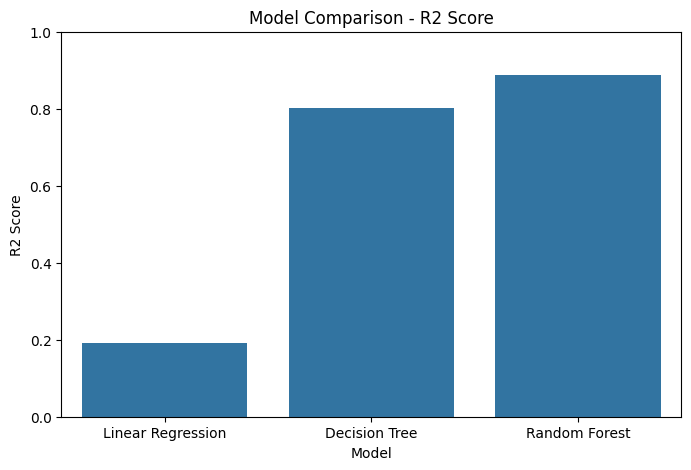

In [12]:
# Actual vs Predicted plot for best model (Random Forest)
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest: Actual vs Predicted Price')
plt.show()

# Model comparison bar chart
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=comparison)
plt.title('Model Comparison - R2 Score')
plt.ylim(0, 1)
plt.show()

## 7. Prediction

In [13]:
# === SAMPLE PREDICTION ===

import numpy as np

# Sample: 2BHK, 800 sqft, Floor 5, 2 Bathrooms, 1 Balcony
sample = pd.DataFrame({
    'location': [le.transform(['thane'])[0]],
    'Carpet Area': [800.0],
    'Floor': [5.0],
    'Bathroom': [2.0],
    'Balcony': [1.0],
    'Transaction_Other': [False],
    'Transaction_Resale': [True],
    'Furnishing_Semi-Furnished': [False],
    'Furnishing_Unfurnished': [False],
    'Ownership_Freehold': [True],
    'Ownership_Leasehold': [False],
    'Ownership_Power Of Attorney': [False]
})

sample_scaled = scaler.transform(sample)
predicted_price = rf.predict(sample_scaled)

print("Property Details: 2BHK, 800 sqft, Floor 5, Thane")
print("Predicted Price per sqft: ₹", round(predicted_price[0], 2))
print("Estimated Total Price: ₹", round(predicted_price[0] * 800, 2))

Property Details: 2BHK, 800 sqft, Floor 5, Thane
Predicted Price per sqft: ₹ 11701.33
Estimated Total Price: ₹ 9361064.0


## 8. Conclusion

In [14]:
# === CONCLUSION ===

# Dataset: Indian Real Estate Listings (87,521 rows after cleaning)
# Target: Price per sqft (in rupees)

# Key Findings:
# 1. Dataset had extreme outliers - max price 6.7M vs median 6,300
# 2. Outlier removal using IQR improved model performance significantly
# 3. MinMaxScaler applied to normalize features

# Model Results:
# Linear Regression : R2 = 0.19 (poor - can't handle non-linear data)
# Decision Tree     : R2 = 0.80 (good)
# Random Forest     : R2 = 0.88 (best - ensemble method wins)

# Best Model: Random Forest with 88% accuracy
# Key lesson: Feature scaling + outlier removal = better models